In [4]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

# Now this works
import aqi_pkg as ap

In [28]:
from datetime import datetime, timedelta
from collections import deque, defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette("colorblind")
plt.style.use("tableau-colorblind10")

from sqlalchemy.dialects.mysql import insert
from tqdm.notebook import tqdm

from sklearn.linear_model import LinearRegression

import aqi_pkg as ap
from aqi_pkg.db import get_session
from aqi_pkg.tables import Entry, MetricAverages, IsDuplicate, UnitConversions
from aqi_pkg.filters import *
from aqi_pkg.data_scripts.create_subindicies import *

import threading


In [6]:
filter = Filter()

dataLoader = DataLoader(
    filters=filter
)

time = datetime.now()
print("Loading data...")

df = dataLoader.get_df(
    remove_duplicates=True,
    hourly_data_only=True)

print(f"Data loaded in {datetime.now() - time}")
print(df.shape)

Loading data...
Data loaded in 0:00:20.410146
(3951633, 17)


In [7]:
df.head()

locationId,last_updated,lat,lon,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB
str,datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""-100165""",2025-11-09 18:00:00,17.765,99.7614,23.5,44.0,328.0,7.5,14.0,4.0,null,8.0,23.5,92.0,25.0,null,null
"""-100165""",2025-11-12 17:00:00,17.765,99.7614,19.0,50.0,723.0,7.0,22.0,1.0,null,9.0,19.0,67.0,33.0,null,null
"""-103042""",2025-11-09 18:00:00,18.5818,98.9932,31.5,55.0,317.5,11.0,19.0,5.0,null,11.0,31.5,89.0,26.0,null,null
"""-103042""",2025-11-12 17:00:00,18.5818,98.9932,33.0,71.0,702.0,6.0,26.0,2.0,null,20.0,28.0,62.0,29.0,null,null
"""-104221""",2025-11-09 18:00:00,18.8029,98.9495,28.0,39.0,446.5,15.0,22.0,6.5,null,7.0,28.0,89.0,26.0,null,null


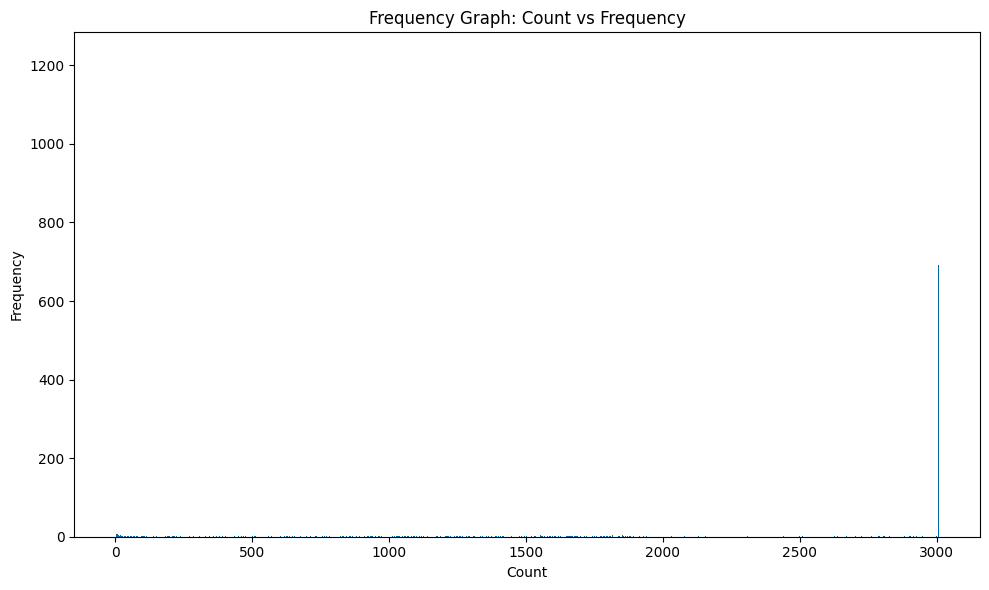

In [8]:
location_counts = (
    df.group_by("locationId")
    .agg(pl.len().alias("len"))
)

count_frequency = (
    location_counts["len"]
    .value_counts()
    .sort("len")
)

plt.figure(figsize=(10, 6))
plt.bar(
    count_frequency["len"].to_list(),
    count_frequency["count"].to_list()
)
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Frequency Graph: Count vs Frequency")
plt.tight_layout()
plt.show()

In [9]:
df_filtered = df.filter(
    pl.len().over("locationId") >= 2500
)

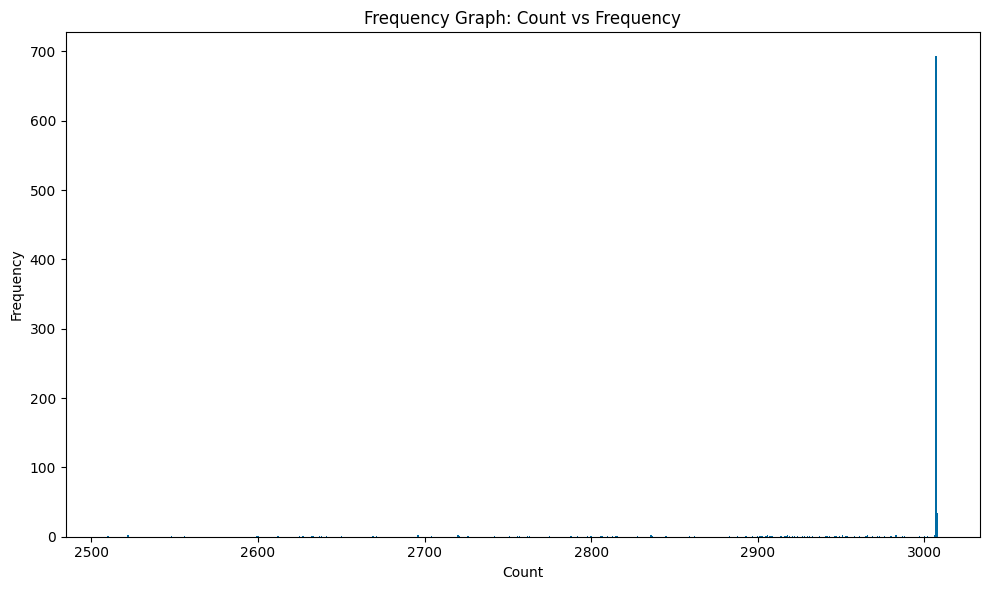

In [10]:
location_counts = (
    df_filtered.group_by("locationId")
    .agg(pl.len().alias("len"))
)

count_frequency = (
    location_counts["len"]
    .value_counts()
    .sort("len")
)

plt.figure(figsize=(10, 6))
plt.bar(
    count_frequency["len"].to_list(),
    count_frequency["count"].to_list()
)
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Frequency Graph: Count vs Frequency")
plt.tight_layout()
plt.show()

In [12]:
df_filtered.shape

(2492836, 17)

In [13]:
print(len(df_filtered["locationId"].unique()))

835


In [21]:
def df_to_dataset(df, target_col, feature_cols, num_hours_lookback):
    df = df.sort(["locationId", "last_updated"])

    exprs = []

    # Create lag features
    for col in feature_cols:
        for i in range(num_hours_lookback):
            exprs.append(
                pl.col(col)
                .shift(i)
                .over("locationId")
                .alias(f"{col}_{i}h")
            )

    exprs.append(
        pl.col(target_col)
        .shift(-1)
        .over("locationId")
        .alias("target")
    )

    df_out = df.with_columns(exprs)

    lag_cols = [f"{col}_{i}h" for col in feature_cols for i in range(num_hours_lookback)]
    df_out = df_out.select(lag_cols + ["target", "locationId", "last_updated"])

    df_out = df_out.drop_nulls()

    return df_out

In [22]:
dataset = df_to_dataset(df_filtered, target_col="PM2_5_UGM3", feature_cols=["PM2_5_UGM3"], num_hours_lookback=3)

In [24]:
print(dataset.shape)
dataset.head()

(2490331, 6)


PM2_5_UGM3_0h,PM2_5_UGM3_1h,PM2_5_UGM3_2h,target,locationId,last_updated
f64,f64,f64,f64,str,datetime[μs]
257.857143,231.5,108.0,303.666667,"""-137557""",2025-11-11 22:00:00
303.666667,257.857143,231.5,387.333333,"""-137557""",2025-11-11 23:00:00
387.333333,303.666667,257.857143,421.0,"""-137557""",2025-11-12 00:00:00
421.0,387.333333,303.666667,425.333333,"""-137557""",2025-11-12 01:00:00
425.333333,421.0,387.333333,412.5,"""-137557""",2025-11-12 02:00:00


In [29]:
models = {}

for location_id, group in tqdm(dataset.group_by("locationId")):
    X = group.select(pl.exclude(["target", "locationId", "last_updated"])).to_numpy()
    y = group["target"].to_numpy()

    model = LinearRegression()
    model.fit(X, y)

    models[location_id] = model

835it [00:00, 1300.56it/s]


835it [00:00, 2522.61it/s]


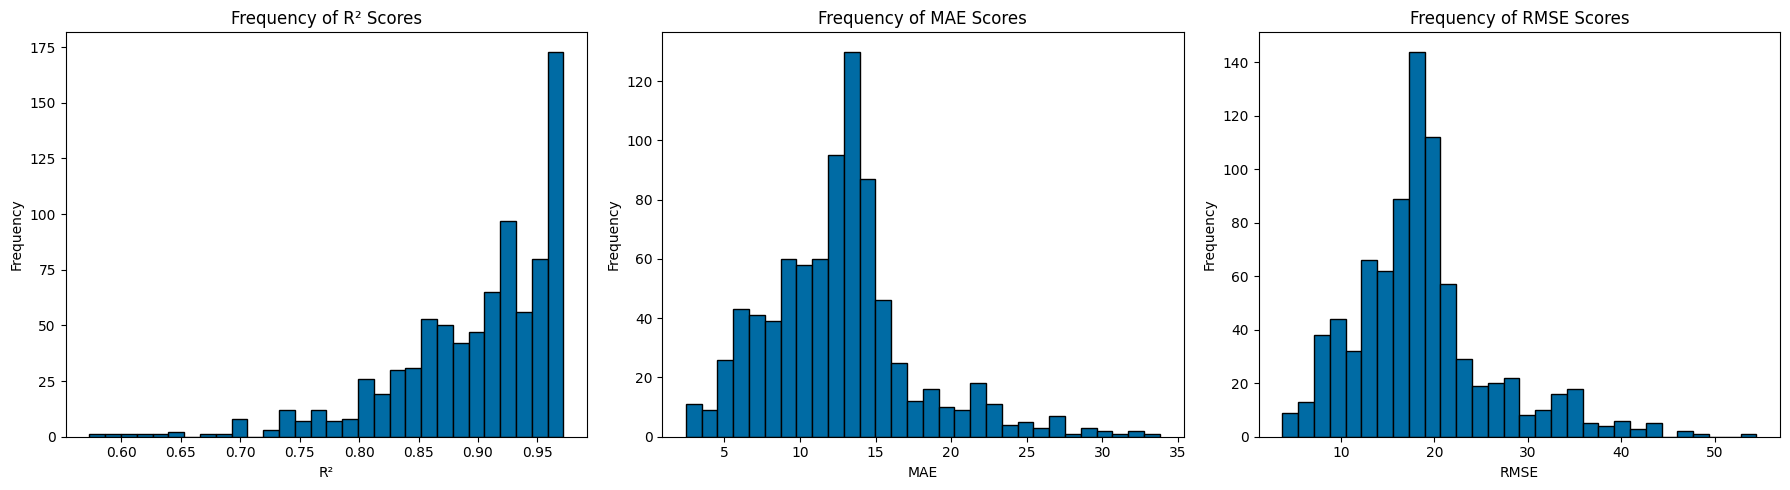

locationId,r2,mae,rmse
str,f64,f64,f64
"""PLLODA000133""",0.971806,11.467464,16.279798
"""10116""",0.971754,11.31161,16.26934
"""PLLODA000533""",0.970615,11.622124,16.478102
"""PLLODA000719""",0.970009,11.678678,16.175664
"""11863""",0.969747,12.244666,17.598122
"""PLLODA000358""",0.969472,11.654616,16.252065
"""10111""",0.969331,11.779433,16.404643
"""PLLODA000651""",0.969203,13.657651,19.179986
"""12466""",0.969166,12.912515,18.265627


In [31]:
performance_rows = []

for location_id, group in tqdm(dataset.group_by("locationId")):
    model = models.get(location_id)
    if model is None:
        continue

    X = group.select(pl.exclude(["target", "locationId", "last_updated"])).to_numpy()
    y_true = group["target"].to_numpy()
    y_pred = model.predict(X)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

    performance_rows.append({
        "locationId": location_id[0] if isinstance(location_id, tuple) else location_id,
        "r2": r2,
        "mae": mae,
        "rmse": rmse,
    })

performance_df = pl.DataFrame(performance_rows).sort("r2", descending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(performance_df["r2"].to_list(), bins=30, edgecolor="black")
axes[0].set_title("Frequency of R² Scores")
axes[0].set_xlabel("R²")
axes[0].set_ylabel("Frequency")

axes[1].hist(performance_df["mae"].to_list(), bins=30, edgecolor="black")
axes[1].set_title("Frequency of MAE Scores")
axes[1].set_xlabel("MAE")
axes[1].set_ylabel("Frequency")

axes[2].hist(performance_df["rmse"].to_list(), bins=30, edgecolor="black")
axes[2].set_title("Frequency of RMSE Scores")
axes[2].set_xlabel("RMSE")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

performance_df